In [1]:
import numpy as np
from scipy.spatial import Delaunay
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget   # 按需打开

# ======== 真函数 ========
def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])
    return 2.0*(x - 3.0)**2 + 3.0*(y - 5.0)**2

def build_reusable_model():
    """一个可复用的小模型：lam[0..2], x,y, As；顶点坐标与f值用mutable Param承载"""
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    m.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
    m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(3)) == 1.0)

    # 顶点数据（可变参数）
    m.vx = pyo.Param(range(3), initialize=0.0, mutable=True)
    m.vy = pyo.Param(range(3), initialize=0.0, mutable=True)
    m.fv = pyo.Param(range(3), initialize=0.0, mutable=True)

    # x,y 与 lam 的链接
    m.x_link = pyo.Constraint(expr=m.x == sum(m.lam[j]*m.vx[j] for j in range(3)))
    m.y_link = pyo.Constraint(expr=m.y == sum(m.lam[j]*m.vy[j] for j in range(3)))

    # As（分片线性插值）
    m.As = pyo.Var()
    m.As_con = pyo.Constraint(expr=m.As == sum(m.lam[j]*m.fv[j] for j in range(3)))

    # 目标（先放个dummy，会在每个单形前重置）
    m.obj = pyo.Objective(expr=0.0, sense=pyo.minimize)
    return m

def set_triangle_to_model(m, verts_xy, fverts):
    """把当前单形的三顶点数据写进可变参数"""
    for j in range(3):
        m.vx[j].set_value(float(verts_xy[j,0]))
        m.vy[j].set_value(float(verts_xy[j,1]))
        m.fv[j].set_value(float(fverts[j]))
    # 重置目标
    m.obj.expr = 2*(m.x - 3)**2 + 3*(m.y - 5)**2 - m.As

# ======== 每个三角形里求 ms/LB/UB（复用同一模型） ========
def minimize_on_each_triangle(nodes, values, solver='ipopt', tee=False, m=None, opt=None):
    pts  = np.asarray(nodes, dtype=float)
    vals = np.asarray(values, dtype=float)
    tri = Delaunay(pts)

    m = m or build_reusable_model()
    opt = opt or pyo.SolverFactory(solver)

    results = []
    for k, simp in enumerate(tri.simplices):
        verts = pts[simp]     # (3,2)
        fverts= vals[simp]    # (3,)
        set_triangle_to_model(m, verts, fverts)

        res = opt.solve(m, tee=tee)
        x_ms = np.array([pyo.value(m.x), pyo.value(m.y)], dtype=float)
        ms_val = float(pyo.value(m.obj))     # min_x [f - As]
        f_at_x_ms = f_true_numpy(x_ms)

        LB = float(np.min(fverts) + ms_val)  # min As + ms = min f(v) + ms
        UB = float(min(np.min(fverts), f_at_x_ms))  # 报告用

        results.append({
            "simplex_index": int(k),
            "vertices_index": simp.tolist(),
            "verts": verts,
            "fverts": fverts,
            "x_ms": x_ms,
            "ms": ms_val,
            "LB": LB,
            "UB": UB,
            "f(x_ms)": f_at_x_ms,
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })
    return tri, results, m, opt

# ======== min-node口径的全局LB ========
def compute_lb_min_node_max_ms(nodes, values, per_tri):
    idx_min = int(np.argmin(values))
    ms_candidates = [r['ms'] for r in per_tri if idx_min in r['vertices_index']]
    if ms_candidates:
        return float(values[idx_min] + max(ms_candidates)), idx_min, float(max(ms_candidates))
    # 退化回退
    fallback = float(min(r['LB'] for r in per_tri))
    return fallback, idx_min, float('nan')

# ======== 选择“ms最小点”，若过近则选次小 ========
def pick_candidate_by_ms_rank(per_tri, nodes, min_dist=1e-6, region_checker=None):
    """
    在 per_tri 中按 ms 升序选 x_ms：
      - 与已有 nodes 的最小距离 >= min_dist
      - 若给了 region_checker，则还必须通过 region_checker(p) 判定（如“落在 active 区域内”）
    """
    cands = sorted(per_tri, key=lambda r: r['ms'])  # ms 最小优先

    def far_enough(p):
        return all(np.linalg.norm(p - q) >= min_dist for q in nodes)

    for rank, r in enumerate(cands, start=1):
        p = np.array(r['x_ms'], float)
        if not far_enough(p):
            continue
        if (region_checker is not None) and (not region_checker(p)):
            continue
        return p, rank, float(r['ms'])
    return None, None, None


# ======== 打印逐单形表 ========
def print_per_triangle_table(results, active_mask):
    results = sorted(results, key=lambda r: r["simplex_index"])
    simplex_ids = [r["simplex_index"] for r in results]
    active_set = {sid for sid in simplex_ids if active_mask.get(sid, False)}

    header = ["row\\simp"] + [f"T{sid}{'*' if sid in active_set else ''}" for sid in simplex_ids]
    rows = [
        ["UB"] + [f"{r['UB']:.6f}" for r in results],
        ["LB"] + [f"{r['LB']:.6f}" for r in results],
        ["ms"] + [f"{r['ms']:.3e}" for r in results],
    ]
    table = [header] + rows

    ncols = len(header)
    colw = [max(len(str(row[c])) for row in table) + 2 for c in range(ncols)]
    RED = "\033[31m"; RESET = "\033[0m"

    def colorize_if_active(c, s):
        if c == 0: return s
        sid = simplex_ids[c-1]
        return f"{RED}{s}{RESET}" if sid in active_set else s

    print("\n== Per-triangle summary ==")
    header_line = "".join(colorize_if_active(c, str(header[c]).ljust(colw[c])) for c in range(ncols))
    print(header_line); print("-" * sum(colw))
    for r in rows:
        line = []
        for c in range(ncols):
            cell = str(r[c])
            padded = cell.ljust(colw[c]) if c == 0 else cell.rjust(colw[c])
            line.append(colorize_if_active(c, padded))
        print("".join(line))
    print("(红色列 = active；第1行=UB，第2行=LB，第3行=ms)\n")

# ======== 作图（保持你原先风格） ========
def plot_iteration(iter_id, nodes, tri, active_mask,
                   grid_n=60, elev=35, azim=-135,
                   min_node=None, new_node=None,
                   per_tri=None):
    nodes = np.asarray(nodes, float)
    COLOR_SURFACE = 'C0'
    COLOR_NODE_EDGES = '#444444'
    COLOR_PIECE = '#ff7043'
    LW_MAIN = 2.2

    xs = np.linspace(0, 10, grid_n); ys = np.linspace(0, 10, grid_n)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = 2.0*(XX-3.0)**2 + 3.0*(YY-5.0)**2

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(XX, YY, ZZ, alpha=0.35, linewidth=0, antialiased=True, color=COLOR_SURFACE)

    if per_tri is not None and len(per_tri) > 0 and tri is not None:
        faces = []
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False): continue
            verts_xy = r["verts"]; fverts = r["fverts"]; ms_val = r["ms"]
            tri_xyz  = [(verts_xy[i,0], verts_xy[i,1], float(fverts[i] + ms_val)) for i in range(3)]
            faces.append(tri_xyz)
        if faces:
            coll = Poly3DCollection(faces, facecolors=[COLOR_PIECE], edgecolors='none', alpha=0.55)
            ax.add_collection3d(coll)
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False): continue
            verts_xy = r["verts"]; fverts = r["fverts"]; ms_val = r["ms"]
            for i in range(3):
                a_xy = verts_xy[i]; b_xy = verts_xy[(i+1)%3]
                za = float(fverts[i] + ms_val); zb = float(fverts[(i+1)%3] + ms_val)
                ax.plot([a_xy[0], b_xy[0]], [a_xy[1], b_xy[1]], [za, zb], lw=LW_MAIN, c=COLOR_PIECE)

    node_z = np.array([f_true_numpy(p) for p in nodes])
    ax.scatter(nodes[:,0], nodes[:,1], node_z, s=30, c='k', depthshade=False)

    if tri is not None:
        for k, simp in enumerate(tri.simplices):
            if not active_mask.get(k, False): continue
            verts_xy = tri.points[simp]
            for i in range(3):
                a, b = verts_xy[i], verts_xy[(i+1)%3]
                ax.plot([a[0], b[0]], [a[1], b[1]],
                        [f_true_numpy(a), f_true_numpy(b)],
                        lw=LW_MAIN, c=COLOR_NODE_EDGES)
            centroid = np.mean(verts_xy, axis=0)
            ax.scatter([centroid[0]], [centroid[1]], [f_true_numpy(centroid)],
                       marker='^', c=COLOR_NODE_EDGES, s=70, depthshade=False)

    if min_node is not None:
        ax.scatter([min_node[0]], [min_node[1]], [f_true_numpy(min_node)],
                   color='g', s=80, marker='o', label='Current min node')
    if new_node is not None:
        ax.scatter([new_node[0]], [new_node[1]], [f_true_numpy(new_node)],
                   color='b', s=80, marker='o', label='Next node')

    ax.set_title(f"Iteration {iter_id}")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f(x,y)")
    ax.legend(loc='upper left'); ax.view_init(elev=elev, azim=azim)
    plt.tight_layout(); plt.show()

def _barycentric_inside_2d(p, tri_xy, eps=1e-10):
    """
    p: (2,)
    tri_xy: (3,2)
    返回 p 是否在三角形内部（含边），用重心坐标，含数值容差 eps
    """
    a, b, c = tri_xy[0], tri_xy[1], tri_xy[2]
    v0 = c - a
    v1 = b - a
    v2 = p - a
    # 解 v2 = u*v0 + v*v1
    den = v0[0]*v1[1] - v1[0]*v0[1]
    if abs(den) <= eps:
        return False  # 退化三角形
    u = (v2[0]*v1[1] - v1[0]*v2[1]) / den
    v = (v0[0]*v2[1] - v2[0]*v0[1]) / den
    w = 1.0 - u - v
    return (u >= -eps) and (v >= -eps) and (w >= -eps)

def in_active_region(p, active_tris, eps=1e-10):
    """
    p: (2,)
    active_tris: list of per_tri dicts (仅 active 的单形)
    只要 p 落在任意一个 active 三角形里，就返回 True
    """
    for r in active_tris:
        if _barycentric_inside_2d(np.asarray(p, float), np.asarray(r["verts"], float), eps=eps):
            return True
    return False



def plot_convergence(hist, prec=4):
    x  = hist["node_count"]; LB = hist["LB_hist"]; UB = hist["UB_hist"]; ms = hist["ms_hist"]
    plt.figure(figsize=(6,4))
    plt.plot(x, LB, marker='o', label="LB (lower bound)")
    plt.plot(x, UB, marker='s', label="UB (upper bound)")
    plt.xlabel("Number of nodes"); plt.ylabel("Bound value")
    plt.title("Global LB and UB vs Number of Nodes")
    plt.legend(); plt.grid(True); plt.tight_layout()

    plt.figure(figsize=(6,4))
    plt.plot(x, ms, marker='o')
    plt.xlabel("Number of nodes"); plt.ylabel("Global ms (min over active simplices)")
    plt.title("ms vs Number of Nodes (Simplex method)")
    plt.grid(True); plt.tight_layout(); plt.show()

    print("\n==== Summary Table ====")
    fmt = f"{{:.{prec}f}}"
    header = f"{'Nodes':>8s} | {'ms':>12s} | {'LB':>12s} | {'UB':>12s}"
    print(header); print("-" * len(header))
    for n, m_, lb, ub in zip(x, ms, LB, UB):
        print(f"{n:8d} | {fmt.format(m_):>12s} | {fmt.format(lb):>12s} | {fmt.format(ub):>12s}")
    print("-" * len(header)); print(f"{'Total':>8s} | {len(x):>12d}")

# ======== UB 等值线交点（对单个三角形） ========
def ub_cross_points_for_triangle(verts_xy, fverts, ms_val, UB, tol=1e-10):
    """
    输入：三顶点坐标 verts_xy(3,2)、顶点真值 fverts(3,)、本单形 ms、UB
    返回：落在该三角形边上的若干交点（list of np.array([x,y])）
    规则：
      - 以 (f(v_i) + ms) 与 UB 比较，分为 low/eq/high；
      - 对每条“低—高”边做线性插值：t = (UB - low)/(high - low)；
      - 若某顶点 eq（|diff|<=tol），直接把该顶点视为交点。
    """
    fv_ms = np.asarray(fverts, float) + float(ms_val)
    diff  = fv_ms - float(UB)

    lows, highs, equals = [], [], []
    for i, d in enumerate(diff):
        if abs(d) <= tol: equals.append(i)
        elif d < 0:       lows.append(i)
        else:             highs.append(i)

    pts = []
    # 顶点恰等 UB → 直接放入
    for i in equals:
        pts.append(verts_xy[i])

    # 低—高 边的交点
    for i in lows:
        for j in highs:
            lo = fv_ms[i]; hi = fv_ms[j]
            t = (UB - lo) / (hi - lo)
            if 0.0 <= t <= 1.0:
                p = (1.0 - t) * verts_xy[i] + t * verts_xy[j]
                pts.append(p)

    # 去重（同一条边可能产生重复）
    uniq = []
    for p in pts:
        if all(np.linalg.norm(p - q) > 1e-12 for q in uniq):
            uniq.append(p)
    return [np.array(p, float) for p in uniq]

# ======== 主循环 ========
def run_case(max_nodes=10, solver='ipopt', tee=False, plot_grid_n=60,
             record_history=True, make_3d_plots=True,
             only_from_active=True, min_dist=1e-4, active_tol=1e-8,
             use_ub_cut=True, ub_equal_tol=1e-9):
    """
    use_ub_cut=True：按你的新方法做 UB 等值线交点构网
    only_from_active：新点只从 active 单形产生；若无 active 则退回所有单形
    """
    # 初始四角
    nodes = [np.array([0.0,0.0]), np.array([0.0,10.0]),
             np.array([10.0,0.0]), np.array([10.0,10.0])]
    values = [f_true_numpy(p) for p in nodes]

    LB_hist, UB_hist, ms_hist, node_count = [], [], [], []

    m, opt = None, None
    it = 0
    while len(nodes) < max_nodes:
        tri, per_tri, m, opt = minimize_on_each_triangle(nodes, values, solver=solver, tee=tee, m=m, opt=opt)

        UB_global = float(np.min(values))
        LB_iter, idx_min_node, ms_chosen = compute_lb_min_node_max_ms(nodes, values, per_tri)
        ms_iter = min(r['ms'] for r in per_tri)

        if record_history:
            LB_hist.append(LB_iter); UB_hist.append(UB_global)
            ms_hist.append(ms_iter);  node_count.append(len(nodes))

        # active 掩码
        active_mask = { r['simplex_index']: (r['LB'] <= UB_global + active_tol) for r in per_tri }
        active_tris = [r for r in per_tri if active_mask[r['simplex_index']]]

        print(f"\n[iter {it}] UB_global = {UB_global:.6f}, LB_iter = {LB_iter:.6f}, ms_iter(min) = {ms_iter:.3e}")
        print(f"[iter {it}] #simplices = {len(per_tri)}, #active = {len(active_tris)} (tol={active_tol:g})")

        # 打印每轮的逐单形表（保留你的输出风格）
        print_per_triangle_table(per_tri, active_mask)

        # ===== UB 等值线交点（仅active单形）=====
        crossing_pts = []
        if use_ub_cut and len(active_tris) > 0:
            for r in active_tris:
                pts = ub_cross_points_for_triangle(r["verts"], r["fverts"], r["ms"], UB_global, tol=ub_equal_tol)
                crossing_pts.extend(pts)

            # 与已有节点去重
            tmp = []
            for p in crossing_pts:
                if all(np.linalg.norm(p - q) >= min_dist for q in nodes):
                    if all(np.linalg.norm(p - q2) >= 1e-12 for q2 in tmp):
                        tmp.append(p)
            crossing_pts = tmp

        print(f"[iter {it}] #UB-cut crossing points (unique & far enough) = {len(crossing_pts)}")

        # ===== 临时加上交点做重剖分，再算一次 ms，用于选“ms最小点” =====
        nodes_for_ms = list(nodes)
        values_for_ms = list(values)
        if len(crossing_pts) > 0:
            for p in crossing_pts:
                nodes_for_ms.append(np.array(p, float))
                values_for_ms.append(f_true_numpy(p))

        tri2, per_tri2, m, opt = minimize_on_each_triangle(nodes_for_ms, values_for_ms, solver=solver, tee=tee, m=m, opt=opt)

        # 候选集：若只从active来，就筛 per_tri2 中那些“其 3 顶点均在 active 覆盖”的单形
        # 简化做法：仍用 per_tri 的 active_mask 标记原单形；新单形（含交点）不再强制active过滤，避免把唯一的好单形误剔除
        candidates = per_tri2

        # 选新点（ms最小，过近换次小）
        # 若有 active，则只允许在“上一轮 active 单形并集”内选点
        if len(active_tris) > 0:
            region_checker = lambda p: in_active_region(p, active_tris, eps=1e-10)
        else:
            region_checker = None  # 没有 active 就不做区域限制（与原逻辑一致）

        new_node, used_rank, used_ms = pick_candidate_by_ms_rank(
            candidates, nodes, min_dist=min_dist, region_checker=region_checker
        )
        if new_node is None:
            print(f"[iter {it}] All candidate x_ms too close (min_dist={min_dist:g}); stop.")
            break

        # 可视化（用第一次 per_tri 的 active 可视）
        if make_3d_plots:
            plot_iteration(it, nodes, tri, active_mask,
                           grid_n=plot_grid_n,
                           min_node=nodes[idx_min_node],
                           new_node=new_node, per_tri=per_tri)

        # 插值：真正加入 1 个点
        if any(np.linalg.norm(new_node - q) < min_dist for q in nodes):
            print(f"[iter {it}] New node too close to existing; stop.")
            break
        nodes.append(new_node)
        values.append(f_true_numpy(new_node))
        it += 1

        if len(nodes) >= max_nodes:
            break

    return {
        "nodes": np.array(nodes), "values": np.array(values),
        "LB_hist": LB_hist, "UB_hist": UB_hist, "ms_hist": ms_hist,
        "node_count": node_count
    }

# ======== 调用示例 ========
if __name__ == "__main__":
    solver      = "ipopt"  # 或 "gurobi"（非凸需注意）
    max_nodes   = 20
    plot_3d     = True
    record_hist = True

    hist_simp = run_case(
        max_nodes=max_nodes,
        solver=solver,
        tee=False,
        plot_grid_n=60,
        record_history=record_hist,
        make_3d_plots=plot_3d,
        use_ub_cut=True,           # 关键开关：启用 UB 等值线交点
        only_from_active=True,     # 候选优先来自 active
        min_dist=1e-4,
        active_tol=1e-8,
        ub_equal_tol=1e-9
    )

    plot_convergence(hist_simp, prec=4)
    nodes  = hist_simp["nodes"]; values = hist_simp["values"]
    print("\n==== Done ====")
    print(f"Total nodes: {len(nodes)}")
    print(f"Best f among nodes: {np.min(values):.6f}")


UsageError: unrecognized arguments: # 按需打开


In [29]:
import numpy as np
import matplotlib.pyplot as plt

def _as_positive_ms(ms_array, already_positive=False):
    ms_array = np.asarray(ms_array, float)
    return ms_array if already_positive else -ms_array

def _align_by_nodes(nodes_a, y_a, nodes_b, y_b):
    nodes_a = np.asarray(nodes_a, int)
    nodes_b = np.asarray(nodes_b, int)
    common = np.intersect1d(nodes_a, nodes_b)
    ia = {int(n): i for i, n in enumerate(nodes_a)}
    ib = {int(n): i for i, n in enumerate(nodes_b)}
    y_a2 = [y_a[ia[int(n)]] for n in common]
    y_b2 = [y_b[ib[int(n)]] for n in common]
    return common, np.asarray(y_a2, float), np.asarray(y_b2, float)

def plot_compare_LB_ms(res_plf, hist_simp, ms_plf_is_Q_minus_As=True, use_semilogy=True):
    # 分片法
    nodes_plf = np.asarray(res_plf.get("nodes_count") or list(range(len(res_plf["LB_history"]))), int)
    LB_plf    = np.asarray(res_plf["LB_history"], float)
    ms_plf    = _as_positive_ms(np.asarray(res_plf["ms_history"], float),
                                already_positive=not ms_plf_is_Q_minus_As)

    # 单形法
    nodes_s = np.asarray(hist_simp["node_count"], int)
    LB_s    = np.asarray(hist_simp["LB_hist"], float)
    ms_s    = _as_positive_ms(np.asarray(hist_simp["ms_hist"], float), already_positive=False)

    # 对齐横轴（只在共同节点数上比较）
    x_LB, LBp, LBs = _align_by_nodes(nodes_plf, LB_plf, nodes_s, LB_s)
    # ms 序列常从第一轮开始，单独对齐
    x_ms, msp, mss = _align_by_nodes(nodes_plf[:len(ms_plf)], ms_plf, nodes_s[:len(ms_s)], ms_s)

    # —— LB 对比 —— 
    plt.figure(figsize=(6,4))
    plt.plot(x_LB, LBp, marker='o', label='PLF - LB')
    plt.plot(x_LB, LBs, marker='s', label='Simplex - LB')
    plt.axhline(0.0, linestyle='--', linewidth=1, label='True optimum (0)')  # 可选：已知最优
    plt.xlabel("number of nodes"); plt.ylabel("LB")
    plt.title("LB vs number of nodes"); plt.grid(True); plt.legend(); plt.tight_layout()

    # —— ms 对比（正误差 As - Q，越低越好）——
    plt.figure(figsize=(6,4))
    if use_semilogy:
        plt.semilogy(x_ms, msp, marker='o', label='PLF - ms (As - Q)')
        plt.semilogy(x_ms, mss, marker='s', label='Simplex - ms (As - Q)')
    else:
        plt.plot(x_ms, msp, marker='o', label='PLF - ms (As - Q)')
        plt.plot(x_ms, mss, marker='s', label='Simplex - ms (As - Q)')
    plt.xlabel("number of nodes"); plt.ylabel("ms (positive)")
    plt.title("ms vs number of nodes"); plt.grid(True, which='both'); plt.legend(); plt.tight_layout()

    # 简短数值快照
    if len(x_LB):
        print(f"LB@last common node {x_LB[-1]}: PLF={LBp[-1]:.6g}, Simplex={LBs[-1]:.6g}")
    if len(x_ms):
        print(f"ms@last common node {x_ms[-1]}: PLF={msp[-1]:.6g}, Simplex={mss[-1]:.6g}")


k=  5  new_node=(5.0, 5.0)  ms=-125  LB=-32  UB=93
k=  6  new_node=(0.0, 5.0)  ms=-75  LB=-67  UB=8
k=  7  new_node=(10.0, 5.0)  ms=-75  LB=-67  UB=8
k=  8  new_node=(5.0, 0.8333333333333334)  ms=-52.0833  LB=-44.0833  UB=8
k=  9  new_node=(5.0, 9.166666666666666)  ms=-52.0833  LB=-44.0833  UB=8
k= 10  new_node=(5.0, 9.408383911415142e-06)  ms=-50.0001  LB=-42.0001  UB=8
k= 11  new_node=(5.0, 10.0)  ms=-50  LB=-42  UB=8
k= 12  new_node=(5.0, 0.0)  ms=-50  LB=-42  UB=8
k= 13  new_node=(8.020833333333584, 7.5)  ms=-26.5842  LB=-18.5842  UB=8
k= 14  new_node=(1.9791666666664156, 7.5)  ms=-26.5842  LB=-18.5842  UB=8
k= 15  new_node=(1.9791666666664174, 2.5)  ms=-26.5842  LB=-18.5842  UB=8
k= 16  new_node=(8.020833333333583, 2.5)  ms=-26.5842  LB=-18.5842  UB=8
k= 17  new_node=(0.0, 7.5)  ms=-18.75  LB=-10.75  UB=8
k= 18  new_node=(10.0, 7.5)  ms=-18.75  LB=-10.75  UB=8
k= 19  new_node=(0.0, 2.5)  ms=-18.75  LB=-10.75  UB=8
k= 20  new_node=(10.0, 2.5)  ms=-18.75  LB=-10.75  UB=8
k= 21  new_

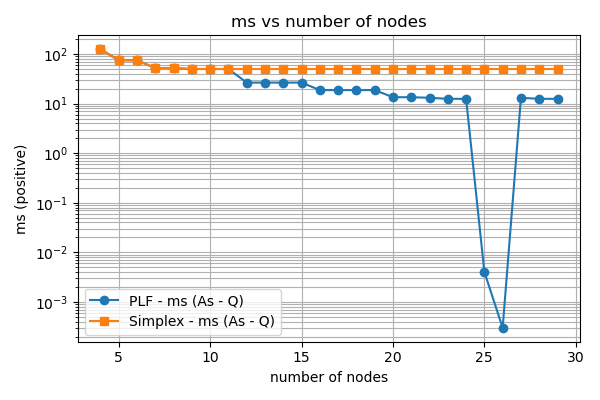

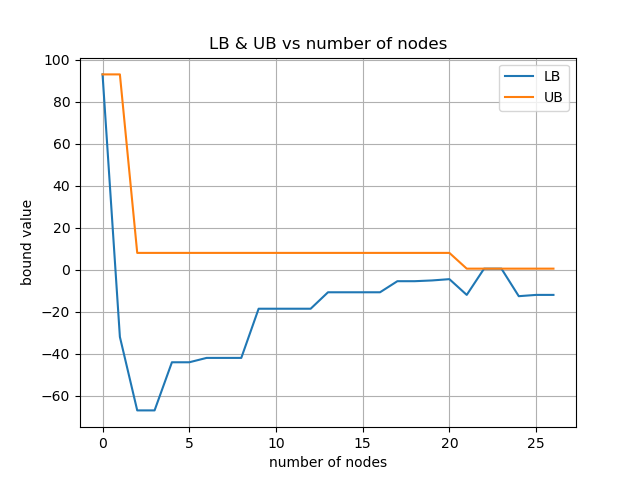

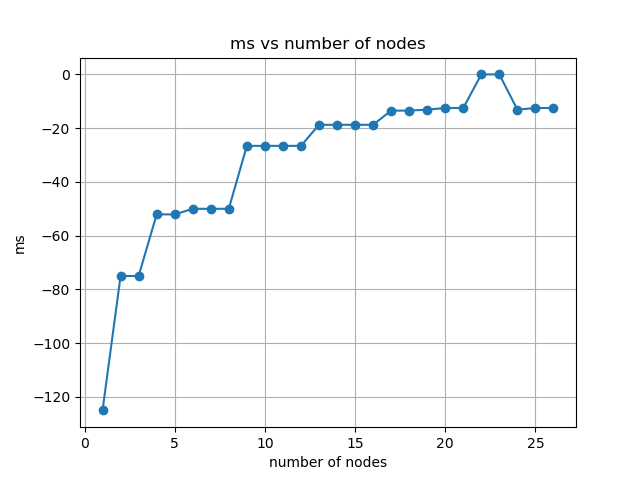

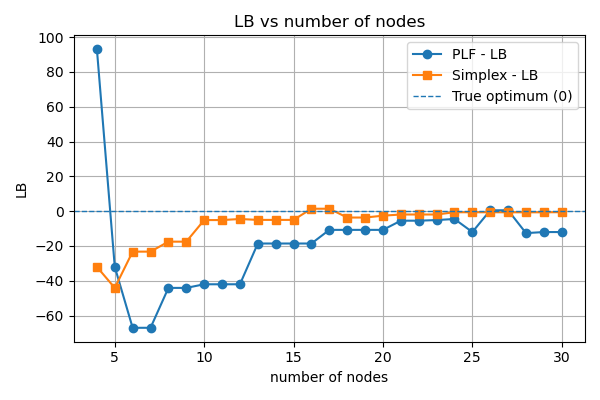

In [30]:
import pyomo.environ as pyo
from pyomo.contrib.piecewise import PiecewiseLinearFunction as PLF
from pyomo.core.base import TransformationFactory
from pyomo.opt import SolverStatus, TerminationCondition
import numpy as np
import matplotlib.pyplot as plt

# ============== 真函数 & 基础模型 ==============
def f_true_numpy(x, y):
    return 2.0*(x - 3.0)**2 + 3.0*(y - 5.0)**2

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    m.obj_expr = pyo.Expression(expr=2.0*(m.x - 3.0)**2 + 3.0*(m.y - 5.0)**2)
    return m, [m.x, m.y]

# ============== 小工具 ==============
USE_DLOG = True  # True=离散对数公式(更紧凑); False=凸组合
def apply_pw_transform(m):
    tx = ("contrib.piecewise.disaggregated_logarithmic"
          if USE_DLOG else "contrib.piecewise.convex_combination")
    TransformationFactory(tx).apply_to(m)

def assert_no_plf_left(m, where=""):
    leftovers = [c.name for c in m.component_objects(PLF, active=True)]
    if leftovers:
        raise RuntimeError(f"[{where}] 未线性化的 PLF: {leftovers}")

def del_components(m):
    for comp in ['obj', 'pw_fun', 'pw_As', 'pw_link']:
        if hasattr(m, comp):
            m.del_component(comp)

def corners_from_bounds(vars_):
    bds = []
    for v in vars_:
        lb, ub = float(v.lb), float(v.ub)
        bds.append((lb, ub))
    # 直积角点
    out = []
    for a in bds[0]:
        for b in bds[1]:
            out.append((a, b))
    return out

def evaluate_Q_at(m, vars_, xy, solver):
    # 固定并求 Q 的最优值（此处Q已无二阶段，所以就是代入值）
    del_components(m)
    x, y = vars_
    x.fix(xy[0]); y.fix(xy[1])
    m.obj = pyo.Objective(expr=m.obj_expr, sense=pyo.minimize)
    # QP，可用Gurobi等
    results = solver.solve(m, tee=False)
    x.unfix(); y.unfix()
    ok = (results.solver.status == SolverStatus.ok and
          results.solver.termination_condition in (TerminationCondition.optimal,
                                                   TerminationCondition.locallyOptimal))
    if not ok:
        raise RuntimeError(f"evaluate_Q_at failed: {results.solver.status}, "
                           f"{results.solver.termination_condition}")
    return pyo.value(m.obj_expr)

def add_nd_piecewise(m, vars_, points, values, name="pw", ndigits=12):
    # 统一：将所有点和查找都经过相同的“keyize”
    def keyize(coords):
        return tuple(round(float(c), ndigits) for c in coords)

    if len(points) == 0:
        raise ValueError("points 不能为空")
    assert len(points) == len(values), "points 与 values 数量不一致"

    # 规范化后的支持点
    norm_points = [keyize(pt) for pt in points]
    # values 也按规范化后的点来建表（避免 numpy 标量/浮点微差）
    table = {}
    for pt, val in zip(points, values):
        k = keyize(pt)
        # 如出现“规范化后重复点”，后写覆盖前写（也可改成求平均）
        table[k] = float(val)

    # 回调函数用相同的 keyize
    def _f(*coords):
        return table[keyize(coords)]

    pw = PLF(points=norm_points, function=_f, name=f"{name}_fun")
    m.add_component(pw.name, pw)
    pw_expr = pw(*vars_)

    As = pyo.Var(name=f"{name}_As")
    m.add_component(As.name, As)
    link = pyo.Constraint(expr=As == pw_expr)
    m.add_component(f"{name}_link", link)
    return As, pw


# ============== 主流程（单场景） ==============
def run_underestimator(target_nodes=30, time_limit=1.0, tee=False):
    # 解算器：Gurobi（QP + MILP）
    solver = pyo.SolverFactory('gurobi')
    solver.options.update({
        'MIPGap': 1e-2,
        'NumericFocus': 1,
        'Presolve': 2,
        'NonConvex': 2,   # 保守些；此处目标是凸QP，设2也OK
        'TimeLimit': time_limit
    })

    # 初始模型 & 角点
    m, vars_ = build_model()
    first_stg_nodes = corners_from_bounds(vars_)  # [(0,0),(0,10),(10,0),(10,10)]
    as_nodes = [evaluate_Q_at(m, vars_, pt, solver) for pt in first_stg_nodes]

    # 历史记录
    LB_hist = []
    UB_hist = []
    ms_hist = []
    nodes_hist = [len(first_stg_nodes)]

    # 初始 UB：取当前节点中 As(=Q) 的最小值
    UB = min(as_nodes)
    UB_node = first_stg_nodes[int(np.argmin(as_nodes))]
    UB_hist.append(UB)
    LB_hist.append(UB)  # 初始可令 LB=UB（也可用 “min As + ms(=0)”）

    # 迭代加点
    while len(first_stg_nodes) < target_nodes:
        # 构建 "min Q - As"
        del_components(m)
        As, _ = add_nd_piecewise(m, vars_, first_stg_nodes, as_nodes, name=f"pw_{len(first_stg_nodes)}")
        m.obj = pyo.Objective(expr=m.obj_expr - As, sense=pyo.minimize)

        apply_pw_transform(m)
        assert_no_plf_left(m, "iter")
        results = solver.solve(m, tee=tee)
        ok = (results.solver.status == SolverStatus.ok and
              results.solver.termination_condition in (TerminationCondition.optimal,
                                                       TerminationCondition.locallyOptimal))
        if not ok:
            print("Warning: solve not optimal:", results.solver.status,
                  results.solver.termination_condition)

        ms = pyo.value(m.obj)                   # 当前 PW 下的最大差值
        new_node = (pyo.value(vars_[0]), pyo.value(vars_[1]))

        # 记录 LB：min As + ms（单场景）
        As_min = min(as_nodes)
        LB = As_min + ms

        # 更新 UB：用当前 “As 最小的节点” 计算 Q（这里就是它本身）
        UB = As_min
        UB_node = first_stg_nodes[int(np.argmin(as_nodes))]

        # 保存历史
        ms_hist.append(ms)
        LB_hist.append(LB)
        UB_hist.append(UB)
        nodes_hist.append(len(first_stg_nodes) + 1)

        # 加入新节点并补表
        first_stg_nodes.append(new_node)
        as_nodes.append(evaluate_Q_at(m, vars_, new_node, solver))

        # 可选：打印一行
        print(f"k={len(first_stg_nodes):3d}  new_node={new_node!r}  ms={ms:.6g}  LB={LB:.6g}  UB={UB:.6g}")

    return {
        "nodes": first_stg_nodes,
        "as_values": as_nodes,
        "LB_history": LB_hist,
        "UB_history": UB_hist,
        "ms_history": ms_hist,
        "nodes_count": nodes_hist,
        "UB_node": UB_node
    }

# ============== 运行并画图 ==============
if __name__ == "__main__":
    # --- 运行分片法 ---
    res = run_underestimator(target_nodes=30, time_limit=1.0, tee=False)

    # （可留可去）分片法自己的两张图
    k_LB = list(range(len(res["LB_history"])))
    k_UB = list(range(len(res["UB_history"])))
    k_ms = list(range(1, 1+len(res["ms_history"])))

    plt.figure()
    plt.plot(k_LB, res["LB_history"], label="LB")
    plt.plot(k_UB, res["UB_history"], label="UB")
    plt.xlabel("number of nodes"); plt.ylabel("bound value")
    plt.title("LB & UB vs number of nodes"); plt.legend(); plt.grid(True)

    plt.figure()
    plt.plot(k_ms, res["ms_history"], marker='o')
    plt.xlabel("number of nodes"); plt.ylabel("ms")
    plt.title("ms vs number of nodes"); plt.grid(True)

    # --- 用你已经存在的 hist_simp 画对比 ---
    # 确保 hist_simp 是一个 dict，含 keys: 'LB_hist','ms_hist','node_count'
    plot_compare_LB_ms(
        res, hist_simp,
        ms_plf_is_Q_minus_As=True,  # 你的 PLF 是 Q-As（负），函数里会转为正误差
        use_semilogy=True
    )

    plt.show()


